# 📊 Notebook 07: Final Model Evaluation & Comparison

**Project Title:** Email Intent Classification with Attention-Based Sequence Models and Priority Prediction  
**Phases Covered:** Phase 8 (Final Evaluation) & Phase 9 (Final Visualizations)

---

### 🎯 Objectives:
1. Load evaluation metrics for all three models:
   - Baseline: TF-IDF + Logistic Regression
   - Deep Learning: Basic LSTM
   - Proposed: LSTM + Attention
2. Compare metrics across Accuracy, Weighted Precision, Weighted Recall, and Weighted F1-Score.
3. Generate consolidated comparison table saved to `results/metrics/final_model_comparison.csv`.
4. Plot comparative performance bar chart (`results/figures/model_comparison.png`).
5. Plot Multi-Class ROC Curves (`results/figures/roc_curve.png`).


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

sns.set_theme(style="whitegrid")

@tf.keras.utils.register_keras_serializable(package="Custom")
class SimpleAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="attention_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )
        super(SimpleAttention, self).build(input_shape)

    def call(self, inputs):
        score = tf.tanh(tf.matmul(inputs, self.W) + self.b)
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = tf.reduce_sum(inputs * attention_weights, axis=1)
        return context_vector


## 1. Consolidated Metrics Comparison Table

In [2]:
lr_m = pd.read_csv("../results/metrics/logistic_regression_metrics.csv")
lstm_m = pd.read_csv("../results/metrics/lstm_metrics.csv")
attn_m = pd.read_csv("../results/metrics/attention_metrics.csv")

comp_df = pd.concat([lr_m, lstm_m, attn_m], ignore_index=True)
comp_df.to_csv("../results/metrics/final_model_comparison.csv", index=False)
comp_df[['Model', 'Architecture', 'Accuracy', 'Precision', 'Recall', 'F1_Score']]


,Model,Architecture,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,TF-IDF + Logistic Regression,0.900000,0.901683,0.900000,0.898718
1,LSTM,Embedding + LSTM + Dense,0.557895,0.588366,0.557895,0.547283
2,LSTM + Attention,Embedding + LSTM + Simple Attention + Dense,0.744737,0.761719,0.744737,0.744522


## 2. Performance Comparison Bar Chart

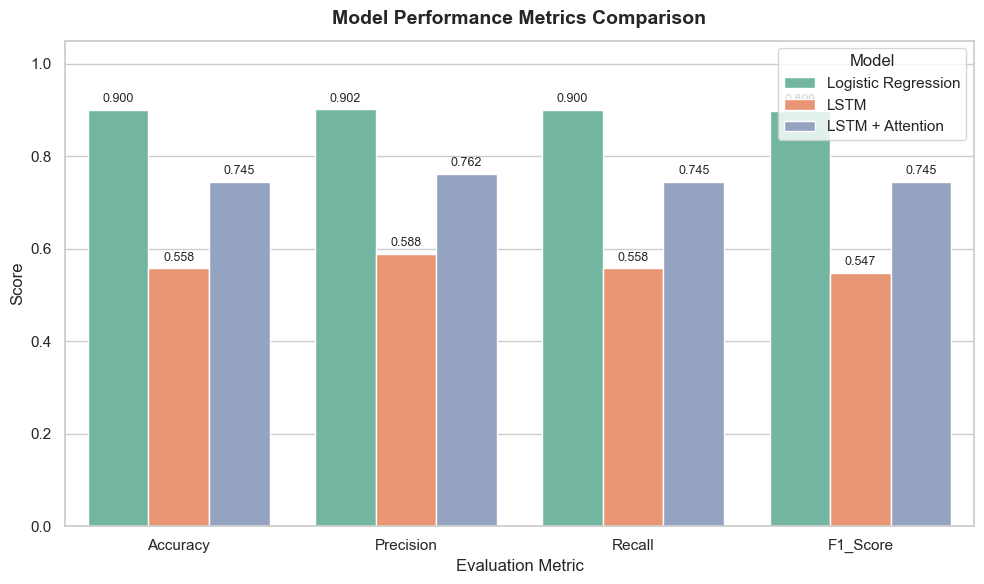

In [3]:
plt.figure(figsize=(10, 6))
df_melted = comp_df.melt(id_vars=['Model'], value_vars=['Accuracy', 'Precision', 'Recall', 'F1_Score'],
                          var_name='Metric', value_name='Score')

ax = sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='Set2')
plt.title("Model Performance Metrics Comparison", fontsize=14, fontweight='bold', pad=12)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.3f}', (p.get_x() + p.get_width() / 2., h + 0.01),
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("../results/figures/model_comparison.png", dpi=300)
plt.show()


## 3. Multi-Class ROC Curve (LSTM + Attention Model)

 1/12 ━━━━━━━━━━━━━━━━━━━━ 5s 478ms/step

 7/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


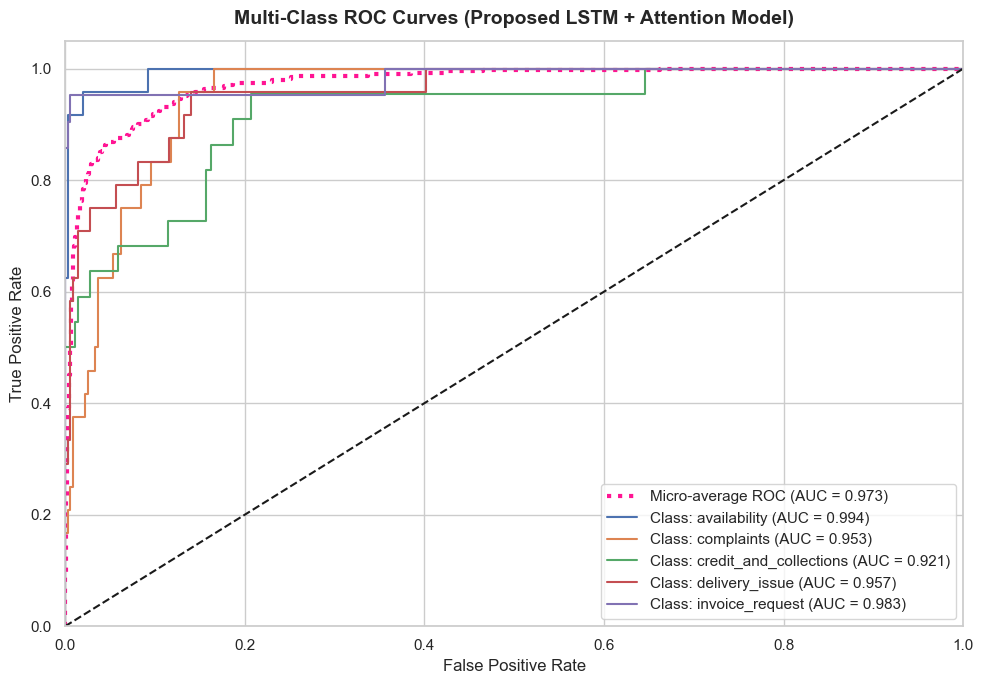

In [4]:
test_df = pd.read_csv("../data/processed/test_emails.csv")
label_encoder = joblib.load("../models/label_encoder.pkl")
tokenizer = joblib.load("../models/tokenizer.pkl")

y_test_num = label_encoder.transform(test_df['intent'])
n_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(y_test_num, classes=range(n_classes))

attn_model = load_model("../models/attention_model.keras", custom_objects={'SimpleAttention': SimpleAttention})
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_email_text']), maxlen=30, padding='post', truncating='post')
y_score = attn_model.predict(X_test_seq)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(10, 7))
plt.plot(fpr["micro"], tpr["micro"], label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.3f})', color='deeppink', linestyle=':', linewidth=3)

for i in range(min(5, n_classes)):
    cls_name = label_encoder.classes_[i]
    plt.plot(fpr[i], tpr[i], label=f'Class: {cls_name} (AUC = {roc_auc[i]:.3f})', linewidth=1.5)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curves (Proposed LSTM + Attention Model)', fontsize=14, fontweight='bold', pad=12)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../results/figures/roc_curve.png", dpi=300)
plt.show()
